# Réseaux de neurones

Pour le moment, on s'est limités à apprendre des fonctions **linéaires** : une régression linéaire, ou encore une classification linéaire. Autrement dit, on s'est limité à des **droites**, des **plans** ou **hyperplans** et à des sommes pondérées en général.

&nbsp;

Une classification/régression linéaire, ça pouvait tout de même nous permettre d'aller loin dans la mesure où on transformait d'abord nos données.

## Régression

**Jeu de données qui n'est pas correctement modélisé par une droite $y = mx + b$** :

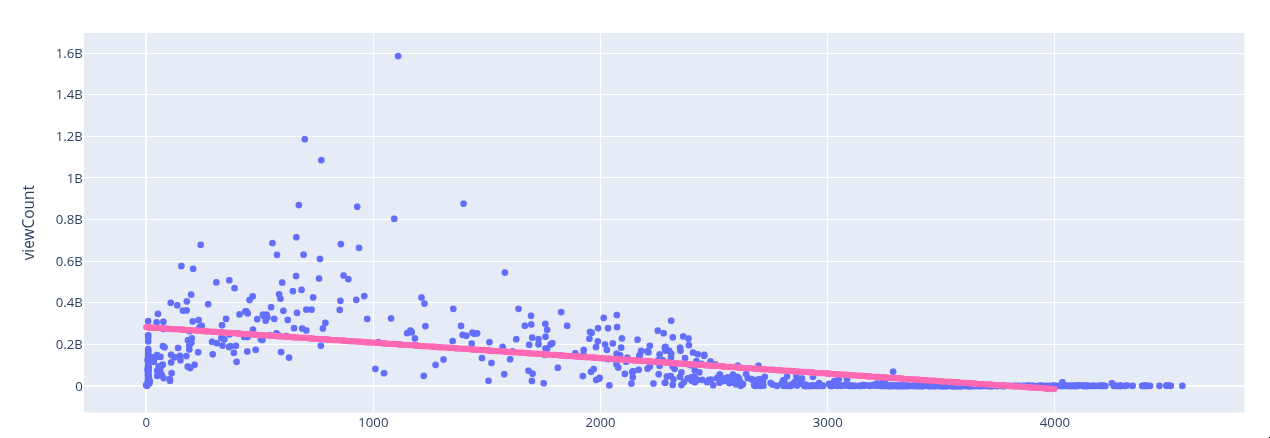

**Régression linéaire apprise sur $y = m_1 x + m_2 x^2 + m_3 x^3 + m_4 x^4 + b$** :

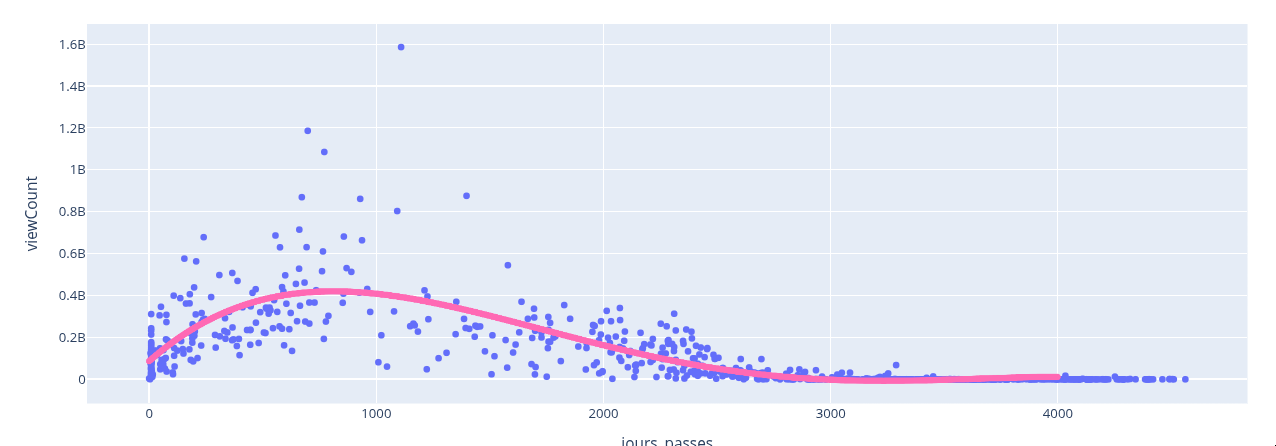

## Classification

**Jeu de données qui ne peut pas être séparé par une droite** :

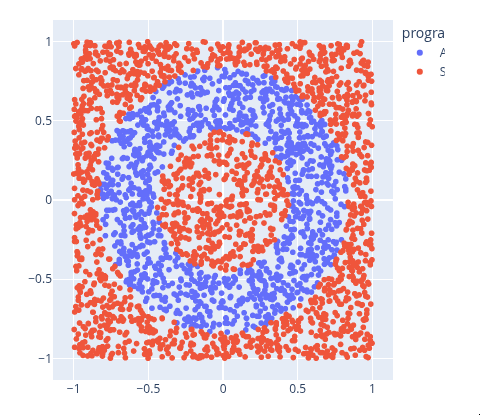

**Transformation pour le rendre séparable linéairement** :

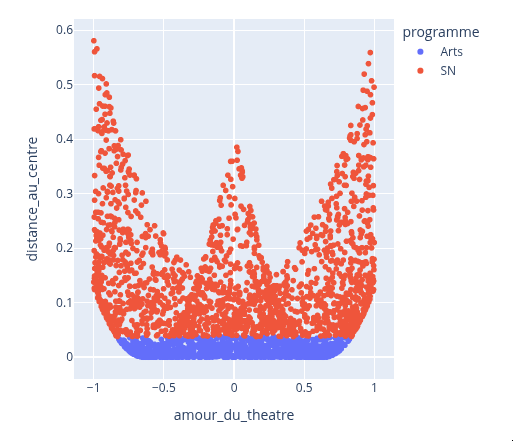

On peut utiliser un SVM sur la deuxième version et avoir des résultats parfaits

## Généraliser le concept : apprendre la non-linéarité

On va se pencher sur un algorithme **non-linéaire**. Les **réseaux de neurones** permettent d'apprendre directement des fonctions plus complexes que des droites.

Le nom "réseau de neurones" peut sonner un peu ésotérique, mais dans sa forme la plus simple, ça reste un algorithme proche de la régression et de la classification linéaire. L'idée de base est relativement simple : **on combine plein de droites ensemble pour approximer une fonction plus complexe**.

In [ ]:
#@title Importations
import numpy as np
import pandas as pd
import plotly.express as px

## Combiner plusieurs droites

Supposons qu'on cherche à apprendre une régression sur les données suivante :

In [ ]:
df_deux_droites = pd.read_csv("https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/exemple-deux-droites.csv")
px.scatter(df_deux_droites, x="x", y="y")

Une seule droite n'est pas suffisante ici. On pourrait transformer les $x$ de ce jeu de données pour transformer en autre chose qui fonctionnerait avec une seule droite, mais essayons autre chose.

**Deux droites** ça ferait l'affaire : une droite qui descend tant que $x < 5$, puis une droite qui monte quand $x >= 5$

&nbsp;

Clairement ici, on veut *deux droites* :

\begin{equation}
y = \begin{cases}
       -2x + 5 &\text{si } x < 5 \\
       +2x - 5 &\text{si } x \ge 5 \\
     \end{cases}
\end{equation}

&nbsp;

Cherchons une solution simple : qu'est-ce qui se passe si on prend la somme de ces deux droites?

\begin{align*}
   y &= -2x + 5 \quad  +  \quad +2x - 5 \\
     &=  (-2x + 2x) + 5 - 5 = 0 \\
  \implies y &= 0
\end{align*}

Hum...

&nbsp;

Essayons autre chose : peut-être une somme pondérée $z_1$ * la première droite + $z_2$ * la deuxième droite, avec $m$ et des $b$ plus compliqués?

\begin{align*}
  y &= z_1 (m_1 x + b_1) + z_2 (m_2 x + b_2)
\end{align*}

On peut simplifier ça...

$$y = z_1 m_1 x + z_1 b_1 + z_2 m_2 x + z_2 b_2$$

On peut regrouper les constantes...

$$y = (z_1 m_1 + z_2 m_2) x + (z_2 b_2 + z_1 b_1)$$

Puisque les $z$, $m$ et $b$ seraient des constantes ici... Peu importe les valeurs qu'on choisirait, on termine donc avec la forme :

\begin{align*}
const_1 &= (z_1 m_1 + z_2 m_2) \\
const_2 &= (z_2 b_2 + z_1 b_1) \\
y &= const_1 x + const_2
\end{align*}


Ce qui correspond à... une seule droite

&nbsp;

**Une somme pondérée de plusieurs droites, c'est forcément une droite.**

## Fonction d'activation

Pour résoudre notre problème, on sait qu'on veut combiner deux droites, mais peu importe ce qu'on fait, une somme pondérée de plusieurs droites, ça va rester une droite.

Si on veut que le résultat de la fonction ne soit *pas* une droite, on doit introduire quelque chose qui empêche ça.

Plutôt que de prendre une somme de deux droites directement, on peut prendre une somme de deux droites *dont le résultat a été passé dans une fonction non-linéaire*, qu'on va appeler la **fonction d'activation**.

&nbsp;

On va combiner (linéairement) des droites avec :

$$y = z_1 f_\text{activation}(m_1 x + b_1) +
z_2 f_\text{activation}(m_2 x + b_2) + c$$

&nbsp;

L'idée ici est exactement la même que quand on faisait une régression non-linéaire à partir d'une régression linéaire.

On fait une régression linéaire $z_1 x_1 + z_2 x_2 + b$ sur des versions transformées de notre $x$ de départ.

&nbsp;

On a beaucoup de choix pour la fonction à mettre ici. La fonction *ReLU* est une option très simple :

\begin{align*}
ReLU(x) &= \begin{cases}
&x \text{ si } x > 0 \\
&0 \text{ sinon}
\end{cases} \\
&= max(x, 0)
\end{align*}

ReLU veut dire **Re**ctified **L**inear **U**nit, ou unité de rectification linéaire. C'est essentiellement une droite dont les négatifs ont été coupés :

In [ ]:
def relu(x):
  return np.maximum(0, x)

x = np.linspace(-10, 10, 100)
y = relu(x)

px.scatter(pd.DataFrame({"x":x, "relu(x)" : y, "f(x) = x" : x}), x="x", y=["f(x) = x", "relu(x)"])

Combiner ensemble deux $ReLU(m x + b)$, ça permet de définir beaucoup de nouvelles formes de fonctions composées de droites :

In [ ]:
#@title Combinaison linéaire de deux transformations ReLU(mx + b)
from ipywidgets import interact

def relu(x):
  return np.maximum(0, x)

x = np.linspace(-10, 10, 80)

def deux_relus(
    z1, z2, c,
    m1, b1,
    m2, b2
    ):
  return z1 * relu(m1 * x + b1) + z2 * relu(m2 * x + b2) + c

def afficher(z1=1., z2=1., c=0., m1=2., b1=5., m2=-2., b2=-5.):
  import matplotlib.pyplot as plt
  df = pd.DataFrame({
      "x": x,
      "deux_relus" : deux_relus(z1, z2, c, m1, b1, m2, b2),
  })
  plt.plot(df['x'], df['deux_relus'], marker='x', linestyle='-', color='blue')
  ax = plt.gca()
  ax.set_xlim([x.min(), x.max()])
  ax.set_ylim([-30, 30])
  plt.grid()
  plt.show()


out = interact(
  afficher,
  c=(-10, +10),
  b1=(-25, 25),
  b2=(-25, 25),
)

interactive(children=(FloatSlider(value=1.0, description='z1', max=3.0, min=-1.0), FloatSlider(value=1.0, desc…

## Comment ça nous aide dans le cas général?

On parle de droites depuis tantôt, mais **avec assez de morceaux de droites, on peut approximer n'importe quoi** (dans la mesure où c'est continu et qu'on veut de la précision sur un intervalle fini).

Considérez la fonction $y = x^2$ :

In [ ]:
x = np.linspace(-10, 10, 30)
y = x**2
df = pd.DataFrame({"x": x, "y": y})
px.scatter(df, x="x", y="y", width=700, height=400)

Combiner des droites passées dans des $ReLU$, ça nous permet de définir une fonction composée de plusieurs morceaux de droites.

On peut se servir de ça pour approximer notre $y = x^2$ :


In [ ]:
# Approximation de la pente entre deux valeurs de x
x = np.linspace(-10, 10, 30)
y = x**2
df = pd.DataFrame({"x": x, "y": y})

def approx_droite(x_debut, x_fin, df):
  debut = df.assign(dist=(df.x - x_debut)**2).sort_values('dist').iloc[0]
  fin = df.assign(dist=(df.x - x_fin)**2).sort_values('dist').iloc[0]
  m = (fin.y - debut.y) / (fin.x - debut.x)
  point = df.assign(dist=(df.x - x_debut)**2).sort_values('dist').iloc[0]
  b = point.y - m*(point.x - x_debut) # x_debut est le décalage horizontal de la droite
  return (m, b)

def segments(x):
  m1, b1 = approx_droite(-10, -5, df)
  m2, b2 = approx_droite(-5, 0, df)
  m3, b3 = approx_droite(0, 5, df)
  m4, b4 = approx_droite(5, 10, df)
  relus = [
      # 4 droites choisies à la main pour approximer la fonction x²
      m1 * relu(x - -10) + b1,
      (m2 - m1) * relu(x - -5),
      (m3-m2)*relu(x - -0),
      (m4-m3)*relu(x -  5)
  ]
  return relus

s = segments(x)

px.line(df.assign(somme_des_segments=sum(s)), x="x", y=["y", "somme_des_segments"], width=700, height=400,range_y=[-5, 105], title="Approximation de x² en combinant 4 segments de droite (via ReLU)", markers=True)

Si ce n'est pas assez précis à notre goût, on peut ajouter plus de segments de droite :

In [ ]:
# Approximation de la pente entre deux valeurs de x
x = np.linspace(-10, 10, 100)
y = x**2
df = pd.DataFrame({"x": x, "y": y})

def approx_droite(x_debut, x_fin, df):
  debut = df.assign(dist=(df.x - x_debut)**2).sort_values('dist').iloc[0]
  fin = df.assign(dist=(df.x - x_fin)**2).sort_values('dist').iloc[0]
  m = (fin.y - debut.y) / (fin.x - debut.x)
  point = df.assign(dist=(df.x - x_debut)**2).sort_values('dist').iloc[0]
  b = point.y - m*(point.x - x_debut) # x_debut est le décalage horizontal de la droite
  return (m, b)

def segments(x):
  relus = []
  m_precedent = None
  step = 1
  for i in np.arange(-10, 10, step):
    m_i, b_i = approx_droite(i, i + step, df)
    if m_precedent is None:
      relus.append(
          m_i * relu(x - i) + b_i
      )
    else:
      relus.append((m_i - m_precedent) * relu(x - i))
    m_precedent = m_i

  return relus

s = segments(x)

px.line(df.assign(somme_des_segments=sum(s)), x="x", y=["y", "somme_des_segments"], width=700, height=400,range_y=[-5, 105], title=f"Approximation de x² en combinant {len(s)} segments de droite (via ReLU)", markers=True)

On résume :

- Une somme pondérée de plusieurs $ReLU(mx + b)$ nous permet de construire une fonction arbitraire définie par des segments de droites
- Avec un assez grand nombre de segments de droite, on peut approximer n'importe quelle fonction non-linéaire continue sur un certain intervalle (quand ce n'est pas assez précis à notre goût, on peut ajouter plus de droites)

## Réseau de neurones

Le **réseau de neurones** est une famille d'algorithmes d'apprentissage.

Dans sa forme la plus simple, un **neurone** est défini comme : **une droite** (plus spécifiquement, une combinaison linéaire, donc droite/plan/somme pondérée en général) **+ une fonction d'activation**

$$neurone(x_1, x_2, ... x_N) = f_\text{activation}(m_1 x_1 + m_2 x_2 + ... + b)$$

Un neurone est une fonction qui reçoit un ensemble de valeurs $x_1, x_2, ... x_N$ et qui retourne un seul nombre scalaire.

On peut représenter un neurone visuellement avec un petit diagramme ([adapté de celui-ci](https://commons.wikimedia.org/wiki/File:Perceptron-unit.svg)) :

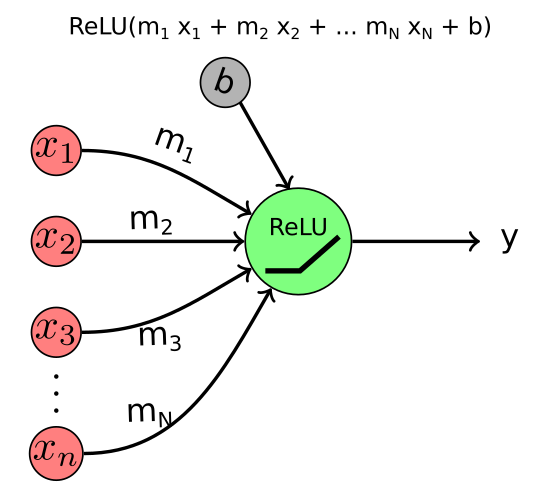

Un neurone a donc :

- $x_i$ : des valeurs d'entrées
- $m_i$ : des poids (coefficients de la droite)
- $b$ : un biais (ordonnée à l'origine de la droite)
- $y$ : une valeur de sortie

&nbsp;

Dans sa version la plus simple, un réseau de neurones consiste à **combiner des neurones en cascade**.

On fait passer nos valeurs d'entrées dans des neurones, dont la sortie est repassée dans d'autres neurones.

Visuellement, on peut dessiner ça :

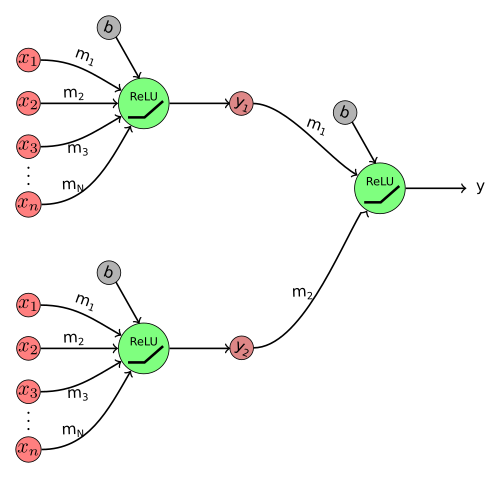

Un réseau de neurones peut être aussi complexe que nécessaire. Voici un graphique qui représente un réseau de neurones à 3 couches cachées, avec un seul neurone de sortie :

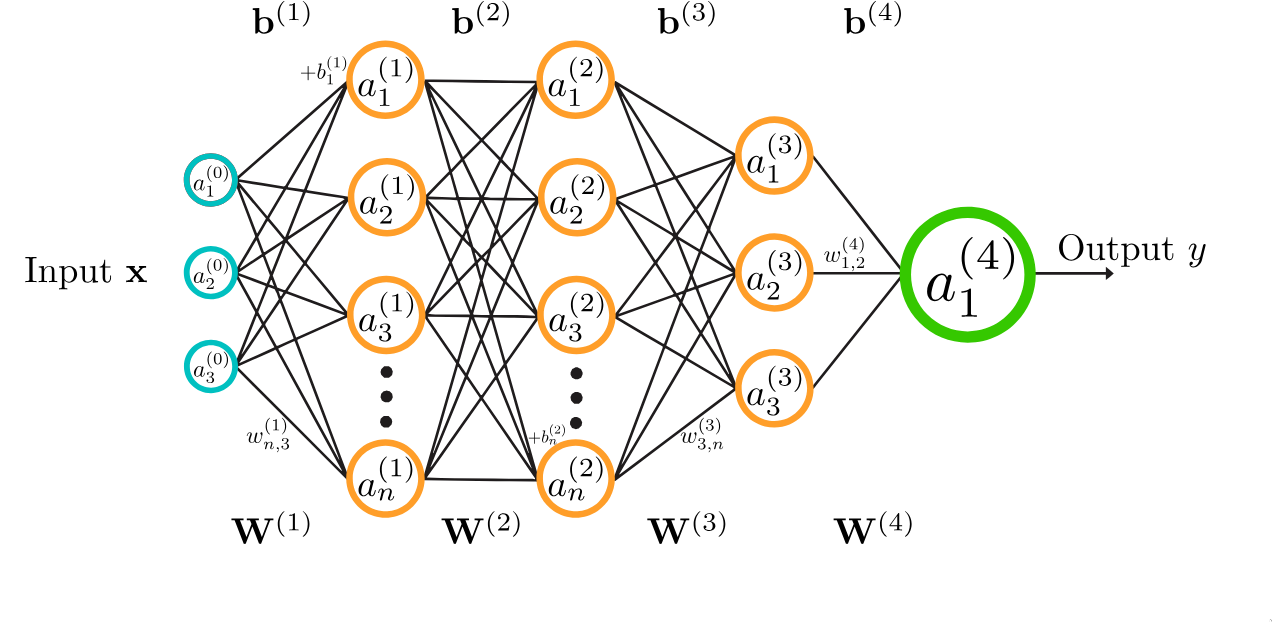

**Terminologie**

Dans un réseau de neurones, on a...

- La **couche d'entrée** : nos caractéristiques $x_1, x_2, \ldots x_N$
- Les **couches cachées** : chaque couche cachée comporte un ensemble de neurones qui font une régression linéaire sur les valeurs calculées par la couche précédente, puis qui passent ça dans leur fonction d'activation
- La **couche de sortie** : la régression ou une classification finale se fait avec le ou les neurones finaux ici.
  * On pourrait par exemple utiliser un dernier neurone sans $ReLU$ à la toute fin, qui correspond simplement à une régression linéaire sur les données transformées
  * On pourrait également se faire un seul neurone final qui correspondrait à une droite de classification linéaire, un peu comme ce qu'on faisait avec SVM

&nbsp;

Un réseau de neurones, on peut voir ça comme une grosse fonction qui combine des $ReLU(mx+b)$ en cascade :

**Première couche cachée**

Chaque neurone est une régression linéaire + un ReLU sur les caractéristiques $x_1, x_2, \ldots x_N$

**Deuxième couche cachée**

Chaque neurone réutilise le résultat de la deuxième couche pour faire une autre régression linéaire + ReLU

**...**

**Couche de sortie**

On a une régression/classification finale sur les données transformées par toutes les couches précédentes.

On définit donc une grosse fonction :

$$f_\text{Reseau de neurones}(x1, x2, ...) = f_\text{couche N}(... f_\text{couche 3}(f_\text{couche 2}(f_\text{couche 1}(x_1, x_2, ...))) ...)$$

Où chaque couche est un ensemble de plusieurs neurones qui combinent les valeurs de sortie obtenues aux couches précédentes.

## Pourquoi le terme "neurone"?

Le terme **neurone** utilisé dans le contexte de l'apprentissage machine est *vaguement* inspiré de la biologie du cerveau, mais ce n'est **pas une simulation d'un vrai cerveau**.

Un "neurone" qui fait une somme pondérée, c'est vaguement analogue à des neurones qui s'envoient des signaux.

Le terme *fonction d'activation* est également à peu près analogue à ce qui se passe avec des neurones. De [wikipédia](https://fr.wikipedia.org/wiki/Fonction_d'activation) :

> Le terme de "fonction d'activation" vient de l'équivalent biologique "potentiel d'activation", seuil de stimulation qui, une fois atteint entraîne une réponse du neurone.

Pour être clair : c'est  **vaguement** inspiré du cerveau.

## Entraînement

La fonction définie par un réseau de neurones est arbitrairement complexe.

&nbsp;

La façon de définir l'erreur commise va dépendre de notre tâche. Pour un réseau de neurones qui apprend une régression, on pourrait par exemple considérer la même fonction de perte qu'une régression linéaire : **l'erreur au carré** (une possibilité parmi beaucoup de choix)

\begin{align*}
f_\text{Reseau de neurones}(parametres) &= f_\text{couche N}(... f_\text{couche 3}(f_\text{couche 2}(f_\text{couche 1}(x_1, x_2, ...))) ...) \\
f_\text{erreur} &= \sum_i^N { (y_i - y_\text{prediction i} )^2 } \\
&=  \sum_i^N { (y_i - f_\text{Reseau de neurones}(x_{i 1}, x_{i 2}, ...) )^2 }
\end{align*}

&nbsp;

Pour un réseau de neurones qui fait de la classification, on pourrait utiliser la pénalité utilisée par SVM (*Hinge loss*).

On cherche alors les paramètres pour chaque neurones qui vont minimiser cette erreur.

&nbsp;

**La minimisation de l'erreur de cette fonction se fait via une descente de gradient**. On n'a aucune chance de réussir à isoler nos variables et de résoudre ça analytiquement.

## Terrain de jeu : *A Machine Learning Playground*

On va aller jouer avec https://playground.scienxlab.org/ pour se donner une intuition de ce qu'un réseau de neurones permet de faire...

Vous devriez reconnaître dans cette interface pas mal de choses dont on a parlé dans les derniers modules :

- *Epoch*
- *Problem type*
- *Loss function*
- *Learning rate*
- *Activation*
- *Regularization*
- *Lambda*
- *Features*
- *Hidden layers*
- *Output*

On va faire un rappel en classe de ce que toutes ces valeurs représentent.

## Exercices

Utilisez le *terrain de jeu* pour réaliser les tests suivants. Notez vos observations.

### Exercice 1.1

- Classification
- Données: premier jeu de données synthétique

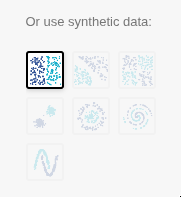

- 0 couche cachée
- Features : $x_1$ et $x_2$
- Loss function : hinge loss (même que pour un SVM)
- Learning rate : 0.001
- Régularisation désactivée

Lancez l'algo avec le bouton vert et regardez la droite converger.

Portez attention aux courbes de la section *Output* et au nombre d'*Epoch* requis avant d'avoir une bonne droite.

Notez les poids (les coefficients) appris pour chaque caractéristique en passant la souris par-dessus une des lignes pointillées.

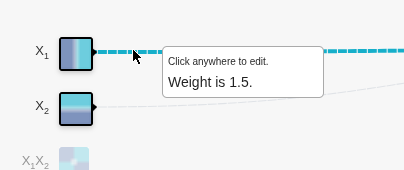

**RÉPONSE**

Puisque les points sont séparables seulement en regardant l'axe horizontal, la droite de classification devrait être verticale (donc ne pas du tout dépendre de $x_2$).

Vous devriez voir que la caractéristique $x_1$ a un poids important, et que la caractéristique $x_2$ a un poids qui se rapproche de zéro.

### Exercice 1.2

Refaites le même exercice (pas de couches cachées), mais avec ce jeu de données de classification linéaire :

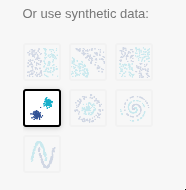

Utilisez un taux d'apprentissage un peu plus élevé : 0.01.

Notez encore les poids (coefficients) attribués à chaque caractéristique.

**RÉPONSE**

$x_1$ et $x_2$ devraient avoir des poids similaires ici, question de donner une droite diagonale

### Exercice 2.1

Essayez un jeu de données plus complexe : le cercle

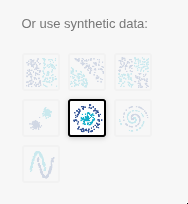

Lancez l'entraînement **en gardant la même configuration** qu'au numéro précédent.

**Expliquez ce qui se passe ici**

**RÉPONSE**

La classification ne devrait pas être bonne, car il est impossible de directement séparer ces données avec une droite.

### Exercice 2.2

On a vu que **faire une classification linéaire sur les données modifiées** était possible dans ce type de situation.

**Toujours avec 0 couche cachée**, essayez d'activer/désactiver certaines caractéristiques d'entrée pour rendre ce jeu de données linéairement séparable.

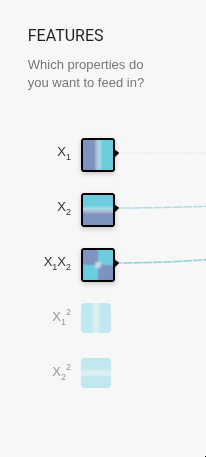

**RÉPONSE**

Plusieurs possibilités fonctionnent bien, par exemple :

- Activer toutes les caractéristiques
- Activer seulement les trois dernières ($x_1 * x_2$, $x_1^2$, $x_2^2$)

### Exercice 3.1

Restez sur le jeu de données en cercles.

&nbsp;

Un réseau de neurones devrait être capable tout seul la non-linéarité, sans qu'on n'ait à lui donner des caractéristiques pré-transformées.

Rétablissez les caractéristiques initiales (seulement $x_1$ et $x_2$) et ajoutez plutôt une couche cachée. Configurez-la pour utiliser 5 neurones, comme ceci :

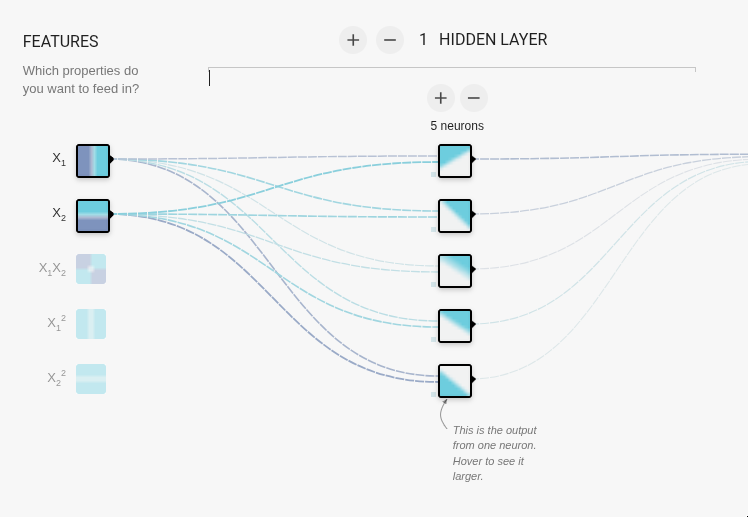

Choisissez la fonction d'action **$ReLU$**, toujours pas de régularisation :

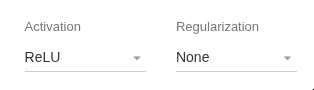

Lancez l'entraînement et observez le résultat

### Exercice 3.2

Portez attention à la forme obtenue pour la classification de ce jeu de données.

Quelque chose de particulier avec les réseaux de neurones est que **la solution que l'algorithme va trouver n'est pas forcément unique**. La descente de gradient trouve **un minimum**, pas forcément le minimum global.

Vous pouvez obtenir des solutions différentes en réinitialisant votre réseau et en relançant l'entraînement de zéro :

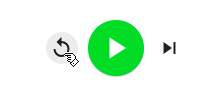

Obtenez-vous toujours la même forme quand vous ré-entraînez le réseau? Faites quelques entraînements différents pour voir à quoi votre fonction peut ressembler

**RÉPONSE**

La zone obtenue pour la classification va varier d'un entraînement à l'autre

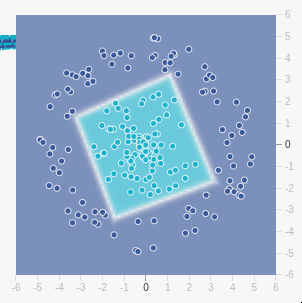

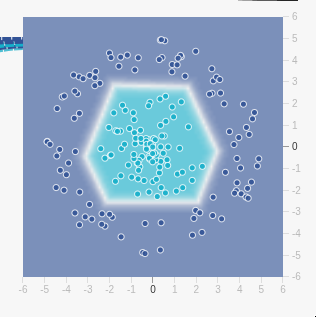

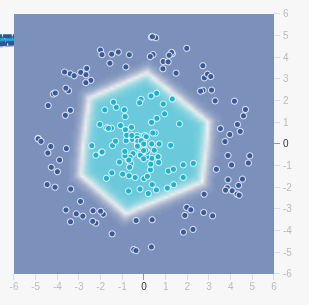

### Exercice 3.3

Quel est le nombre minimum de neurones que vous devez utiliser dans la couche cachée pour avoir une bonne classification sur ce problème?

Testez plusieurs fois l'entraînement du réseau avec différents nombres de neurones et notez vos observations.

**RÉPONSE**

Un seul neurone n'est pas suffisant.

Deux neurones ne sont pas suffisants non plus.

À trois neurones, on peut trouver une solution, mais l'entraînement ne convergera pas toujours vers la solution qu'on cherche. Même chose pour quatre neurones.

### Exercice 3.4

Portez attention à la fonction apprise par chaque neurone individuel dans la couche cachée. En passant la souris sur les petits carrés, vous pouvez visualiser la fonction (blanc = 0, et plus c'est bleu, plus la valeur $y$ est élevé)

Refaites des entraînements, mais avec **8 neurones dans la couche cachée** (le maximum). Chaque neurone de la couche cachée est un $ReLU(m_1 x_1 + m_2 x_2 + b)$, donc vous devriez voir ce qui ressemble à des droites dans chaque petit carré :

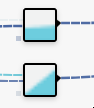

&nbsp;

Faites plusieurs entraînements, et dites :

- Est-ce que les droites apprises par les neurones cachés se ressemblent d'une fois à l'autre?
- Trouvez un cas où deux neurones semblent avoir appris la même chose

**RÉPONSE**

Ça ne se ressemble pas du tout d'une fois à l'autre, les neurones font un peu n'importe quoi qui va changer selon l'état initial.

Les neurones d'une même couche ne se coordonnent pas et apprennent des choses chacun de leur côté. De temps en temps, on va voir des neurones dédoublés : deux fois la même fonction apprise par deux neurones différents. Ça peut être un indice qu'utiliser autant de neurones n'était pas absolument nécessaire.

### Exercice 4.1

Vous pouvez modifier directement les poids appris par la descente de gradient en cliquant sur des lignes pointillées.

Toujours avec le jeu de données en cercle, faites un entraînement, puis mettez-le en pause quand ça converge vers quelque chose de bon.

Choisissez ensuite un des neurones et **désactivez-le**. Cliquez sur la ligne pointillée qui sort de ce neurone, et mettez le poids à zéro :

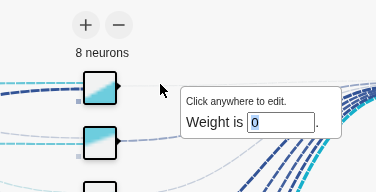

1. Décrivez le résultat
2. Repartez l'entraînement

**RÉPONSE**

La fonction de sortie va se faire amputer d'un morceau, on va le voir sur le résultat.

Si on laisse le réseau continuer de s'entraîner, la fonction devrait reconverger vers quelque chose qui sépare bien les données.

### Exercice 4.2

**Ajoutez une deuxième couche cachée au réseau, avec deux neurones dedans**, comme suit :

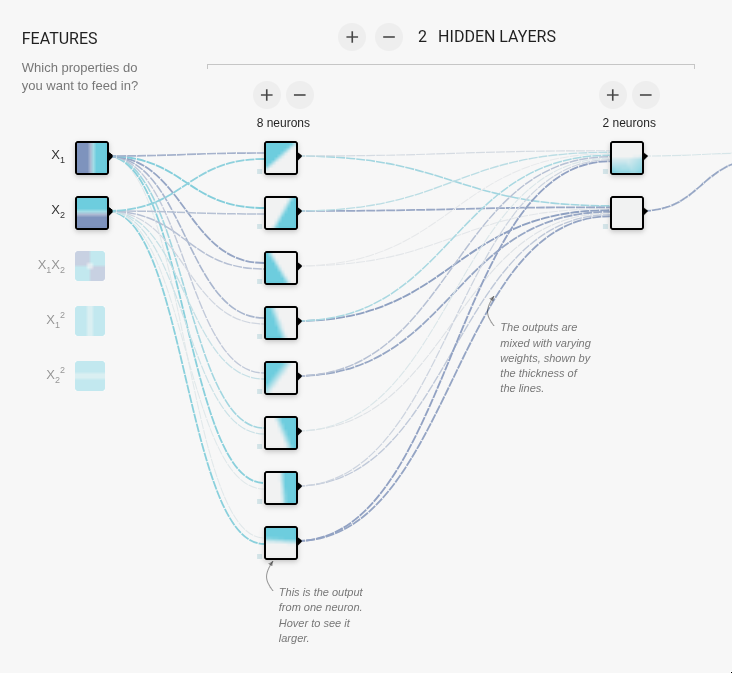

Lancez l'entraînement et observez la forme apprise par les neurones de la deuxième couche.

**RÉPONSE**

La première couche est entièrement composée de ReLU(droites).

La deuxième couche fait un mélange de plusieurs droites, et ce que les neurones de la deuxième couche apprennent a plus l'air d'un cercle.

### Exercice 5.1

Essayez un jeu de données plus complexe :

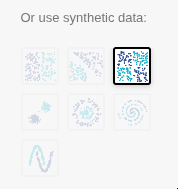

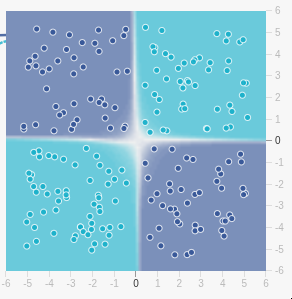

Essayez d'abord : 3 couches cachées de 6 neurones chaque. Faites quelques entraînement pour voir comment le résultat change d'une fois à l'autre.

&nbsp;

**Essayez ensuite de trouver une configuration avec LE MOINS DE NEURONES POSSIBLE**.

Vous pouvez jouer avec le taux d'apprentissage si ça vous aide.

Assurez-vous de garder la fonction $ReLU$ et de n'utiliser **que** $x_1$ et $x_2$ comme caractéristiques d'entrée (c'est trop facile si on ajoute $x_1 x_2$, n'activez pas ça).

**RÉPONSE**

On y va par essai-erreur

De mon côté, couche 1 avec 5 neurones, couche 2 avec 6 neurones, ça fonctionne bien.

### Exercice 5.2

Téléchargez le jeu de données suivant : [https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cercles-concentriques.json](https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cercles-concentriques.json)

Ce jeu de données est similaire à ce qu'on avait fait dans le module sur le SVM, lorsqu'on parlait de linéariser les données manuellement :

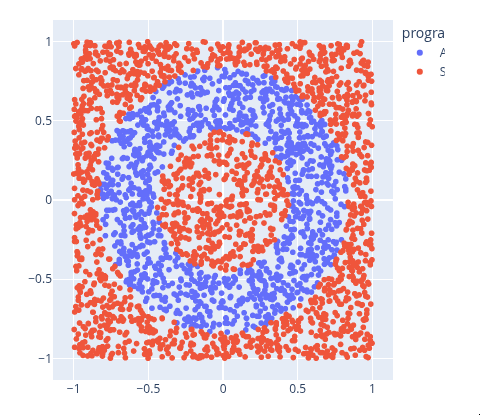

Choisissez l'option **Upload your own JSON**

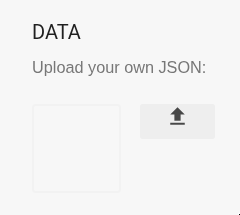

et trouvez une configuration qui permet d'apprendre cette fonction.

### Exercice 5.3

Essayez de trouver une configuration qui marche pour le jeu de données avec deux demi-lunes :

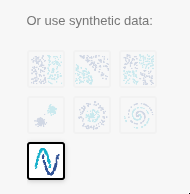

# D'autres fonctions d'activation

Le truc qui permet de combiner linéairement des droites sans finir avec une seule droite, c'est la non-linéarité introduite par la fonction d'activation.

La fonction $ReLU$ est un choix très simple qui fait souvent l'affaire, mais beaucoup, beaucoup d'autres fonctions d'activations peuvent être utilisées. La fonction $tanh$ (tangente hyperbolique) est une autre option intéressante :

In [ ]:
x = np.linspace(-5, 5, 100)
y = np.tanh(x)

px.scatter(pd.DataFrame({"x":x, "tanh(x)" : y, "f(x) = x" : x}), x="x", y=["tanh(x)"])

La courbe de la fonction $tanh$ est beaucoup plus douce et graduelle que le $ReLU$.

En construisant un réseau de neurones avec des $tanh$ plutôt qu'avec des $ReLU$, on combine des courbes plus douces. La fonction apprise est plus *graduelle* :

In [ ]:
#@title Exemples de combinaisons au hasard de deux courbes tanh(mx + b)

np.random.seed(1337)

for i in range(3):
  x = np.linspace(-5, 5, 100)
  y = sum(
      [np.random.normal() * np.tanh(x * np.random.normal() + np.random.normal()) for i in range(2)]
  )

  display(px.scatter(pd.DataFrame({"x":x, "Combinaison linéaire de 2 tanh au hasard" : y, "f(x) = x" : x}), x="x", y=["Combinaison linéaire de 2 tanh au hasard"]))

## Exercices

## Exercice 6.1

Reprenez le jeu de données des cercles :

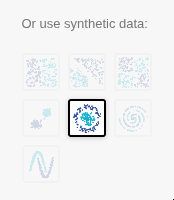

Choisissez la fonction d'activation $tanh$ :

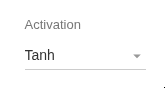

Essayez de trouver une architecture de réseau qui permet d'avoir des bons résultats sur ce jeu de données.

Notez la forme de la fonction apprise par le réseau de neurones.

**RÉPONSE**

De mon côté, j'ai beaucoup plus de facilité à apprendre la fonction avec 3 couches. À une seule couche, ça ne semble pas faisable, peu importe le nombre de neurones.

Plutôt que d'avoir une forme délimitée par des lignes droites, vous devriez finir avec un contour beaucoup plus smooth, par exemple :

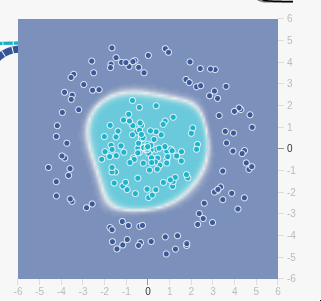

### Exercice 6.2

Trouvez une configuration pour un réseau de neurones qui utilise seulement les caractéristiques $x_1$ et $x_2$ en entrée, pour classifier correctement les deux derniers jeux de données synthétiques :

Commencez avec :

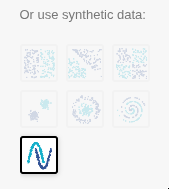

Puis cherchez une configuration qui marche avec :

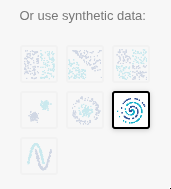

Vous pouvez utiliser la fonction d'activation que vous voulez, le nombre de couches et de neurones que vous voulez, le taux d'apprentissage que vous voulez

**RÉPONSE**

Testez des choses!

Avec les réseaux de neurones, il y a nécessairement une part d'essais-erreurs dans le processus d'entraînement.

# Les réseaux de neurones dans `sklearn`

Des réseaux de neurones simples sont disponibles dans `scikit-learn`, et on les utilise comme tous les autres modèles vus jusqu'à présent.

On utilise les modèles `MLPRegressor` ou `MLPClassifier`.

MLP = ***M**ulti-**L**ayer **P**erceptron*, ou "perceptron multi-couches". Le "perceptron" est le nom qui a été donné au premier neurone artificiel.

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import root_mean_squared_error

# Petit jeu de données
x = np.linspace(-10, 10, 30)
y = 5*x**3 - x**2 + 3*x
df = pd.DataFrame({"x": x, "y": y})

# Mise à l'échelle des données : très important pour les réseaux de neurones.
# La descente de gradient utilisée pour l'entraînement se comporte très mal
# quand les différentes dimensions ne sont pas sur la même échelle
scaler = StandardScaler()
df_echelle = scaler.fit_transform(df)

# Définition du modèle MLPRegression : un réseau de neurones de type "multi-layer-perceptron" (des neurones linéaires en cascade)
modele = MLPRegressor(
    (100, 80, 70, 40),         # Configuration des couches cachées:
                               #          100 neurones à la première couche cachée
                               #          80 neurones à la couche cachée #2
                               #          70 neurones à la couche cachée #3
                               #          40 neurones à la dernière couche cachée
    activation='relu',         # Fonction d'activation (typiquement relu ou tanh)
    learning_rate_init=0.003,  # Taux d'apprentissage
    max_iter=2000,             # Nombre d'itérations autorisé pour la descente de gradient
    random_state=121,          # "random seed" pour l'initialisation des paramètres
)
modele.fit(df_echelle[:, 0:1], df_echelle[:, 1])


y_prediction = modele.predict(df_echelle[:, 0:1].reshape(-1, 1))
display(px.line(pd.DataFrame(df_echelle, columns=['x', 'y']).assign(y_prediction=y_prediction), x="x", y=["y", "y_prediction"], width=700, height=400))

print("Nombre d'époques total pour l'apprentissage:", modele.n_iter_)
print("Erreur RMSE d'entraînement:", root_mean_squared_error(df_echelle[:, 1], y_prediction))

Nombre d'époques total pour l'apprentissage: 72
Erreur RMSE d'entraînement: 0.0280678630590906


**Notez** : puisque l'entraînement d'un réseau de neurones se fait via une descente de gradient, on a également l'option d'utiliser **`partial_fit()`**, pour exécuter une seule époque d'entraînement à la fois.

## Exercice 7 : Compter le nombre de paramètres

Déterminez le nombre de **paramètres** à apprendre pour les algos suivants :

1. `LinearRegression()` qui prend en entrée 10 caractéristiques au sujet d'une personne et qui prédit son âge

2. Un SVM entraîné pour détecter si un titre de nouvelle provient du journal The Onion ou non à partir d'un sac-de-mots, avec un vocabulaire de 30 000 mots.

3. Un réseau de neurones qui prend en entrée 10 caractéristiques au sujet d'une personnage et qui prédit son âge, avec la configuration suivante :
    - 10 valeurs dans la couche d'entrée
    - 100 neurones $ReLU$ dans la première couche cachée
    - 200 neurones $ReLU$ dans la couche cachée #2
    - 150 neurones $ReLU$ dans la couche cachée #3
    - 250 neurones $ReLU$ dans la couche cachée #4
    - 180 neurones $ReLU$ dans la couche cachée #5
    - 1 neurone linéaire de sortie


**RÉPONSE**

1. La régression linéaire doit apprendre un coefficient par caractéristique + l'ordonnée à l'origine. Ici, ça nous fait 10 coefficients + 1 = **11 paramètres** au total

---

2. Un SVM apprend aussi une droite, un coefficient par dimension + une ordonnée à l'origine. On a $30~000$ dimensions dans la valeur en entrée, donc $30~001$ paramètres à apprendre.

---

3. Dans un réseau de neurones, **chaque neurone apprend à faire une régression linéaire sur les valeurs de la couche précédente**

- Couche cachée #1 : À la première couche, on a 100 neurones, donc 100 régressions linéaires à faire sur 10 entrées, ce qui nous fait 100 neurones * (10 + 1 paramètres/neurone) = 1100 paramètres.

- Couche cachée #2 : 200 * (100 + 1)

- Couche cachée #3 : 150 * (200 + 1)

- Couche cachée #4 : 250 * (150 + 1)

- Couche cachée #5 : 180 * (250 + 1)

- Couche de sortie : 1 * (180 + 1)

**Total:**   $1 * (180 + 1) + 180 * (250 + 1) + 250 * (150 + 1) + 150 * (200 + 1) + 200 * (100 + 1) + 100 * (10 + 1) = 134~561$

Vous devirez voir que **le nombre de paramètres à apprendre dans un réseau de neurones monte vite**.

Une conséquence importante de cette observation est que **la taille de notre jeu de données doit être beaucoup plus grosse quand on souhaite entraîner un réseau de neurones** plutôt qu'un autre algorithme plus simple.

Une heuristique commune est : **au moins $10~000$ observations dans le jeu de données**, possiblement plus que ça pour apprendre des choses plus complexes.

# Capacité des réseaux de neurones

**Un réseau de neurones assez complexe peut apprendre n'importe quoi.**

Voici une petit démo pour tester par vous-mêmes : dessinez une fonction arbitraire dans la case suivante, et un réseau de neurones va tenter d'apprendre votre fonction.

In [ ]:
from IPython.display import HTML, Image
from google.colab.output import eval_js
from base64 import b64decode

def dessin(filename='drawing.png', w=400, h=400):
  """Adapté de : https://gist.github.com/korakot/8409b3feec20f159d8a50b0a811d3bca"""
  from IPython.display import clear_output
  import cv2
  import numpy as np
  canvas_html = """
  <canvas width=400 height=400 style="width: 800px; height: 800px; border: 1px solid black;"></canvas>
  <br>
  <button>Sauvegarder l'image</button>
  <script>
  var canvas = document.querySelector('canvas')
  var ctx = canvas.getContext('2d')
  ctx.fillStyle = "black";
  ctx.fillRect(0, 0, 400, 400);
  var button = document.querySelector('button')
  var mouse = {x: 0, y: 0}
  var lastPoint = {x: 0, y: 0}

  canvas.addEventListener('mousemove', function(e) {
    lastPoint.x = mouse.x;
    lastPoint.y = mouse.y;
    mouse.x = Math.round((e.pageX - this.offsetLeft)/2)
    mouse.y = Math.round((e.pageY - this.offsetTop)/2)
  })
  canvas.onpointerdown = (e)=>{
    // ctx.beginPath()
    // ctx.moveTo(mouse.x, mouse.y)
    canvas.addEventListener('mousemove', onPaint)
    onPaint();
    canvas.setPointerCapture(e.pointerId);
  }
  canvas.onpointerup = (e)=>{
    canvas.removeEventListener('mousemove', onPaint)
    canvas.releasePointerCapture(e.pointerId);
  }
  var onPaint = ()=> {
    let putPixel = (x, y) => {
      // Wipe la colonne
      ctx.fillStyle = "black";
      ctx.fillRect(x, 0, 1, 400);

      ctx.fillStyle = "white";
      ctx.fillRect(x, y, 1, 1);
    };

    // https://en.wikipedia.org/wiki/Digital_differential_analyzer_(graphics_algorithm)
    let xStart = lastPoint.x;
    let xEnd = mouse.x;
    let yStart = lastPoint.y
    let yEnd = mouse.y;

    let dx = (xEnd - xStart);
    let dy = (yEnd - yStart);

    if(dx == 0 && dy == 0) {
      putPixel(xStart, yStart);
      return;
    }

    let step = Math.abs(dy);

    if (Math.abs(dx) >= Math.abs(dy))
      step = Math.abs(dx);

    dx = dx / step;
    dy = dy / step;

    let x=xStart;
    let y = yStart;
    let i = 0;

    while(i <= step) {

      let xInt = Math.round(x);
      let yInt = Math.round(y);

      putPixel(xInt, yInt);

      x += dx;
      y += dy;
      i++;
    }
  }

  var data = new Promise(resolve=>{
    button.onclick = ()=>{
      resolve(canvas.toDataURL('image/png'))
    }
  })
  </script>
  """
  disp = display(HTML(canvas_html))
  data = eval_js("data")
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  clear_output()
  img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(img, (400, 400))
  # Flip vertical
  img = img[::-1, :]
  cv2.imwrite("drawing.png", img)
  return img

def dessiner_fct():
  arr = dessin()
  pts = []
  for y, ligne in enumerate(arr):
    for x, val in enumerate(ligne):
      if val:
        pts.append((x, y))
  # Points originaux
  pts = np.array(pts)
  assert len(pts) > 0, "Aucun point dans le dessin"
  n_points_requis = 10_000
  if len(pts) < n_points_requis:
    times = n_points_requis // len(pts) + 1
    pts = np.concat([pts] * times)
    pts = pts + np.random.normal(size=pts.shape)
  df = pd.DataFrame(pts, columns=['x', 'y'])
  display(px.scatter(df, x="x", y="y", title="Votre fonction"))
  return pts

pts = dessiner_fct()
scaler = StandardScaler()
pts = scaler.fit_transform(pts)

reseau_de_neurones = MLPRegressor((200,200,200,200,200,200), 'relu', max_iter=20000)
print("Début de l'entraînement du réseau de neurones...")
reseau_de_neurones.fit(pts[:, :-1], pts[:, -1])
print("Solution trouvée en", reseau_de_neurones.n_iter_, "itérations")
y_prediction = reseau_de_neurones.predict(pts[:, :-1])
px.scatter(pd.DataFrame(pts, columns=['x', 'y']).assign(y_prediction=y_prediction), x="x", y=["y", "y_prediction"])

Début de l'entraînement du réseau de neurones...
Solution trouvée en 14 itérations


## Théorèmes d'approximation universelle

J'ai essayé à travers les démos de vous faire une démonstration intuitive du fait qu'il était *possible* de construire une somme pondérée de $ReLU()$ qui approxime n'importe quelle fonction continue.

On peut prouver ça formellement : plusieurs personnes se sont attelées à la tâche de démontrer différents **[Théorèmes d'approximation universelle](https://fr.wikipedia.org/wiki/Th%C3%A9or%C3%A8me_d%27approximation_universelle)**. Un réseau de neurones, pourvu qu'on lui donne assez de neurones, peut approximer n'importe quelle fonction continue (sous certaines petites contraintes).

&nbsp;

D'autres architectures de réseaux de neurones plus complexes (ex.: les *réseaux de neurones récurrents*, ou encore les *"transformers"* utilisés par ChatGPT) vont même jusqu'à être **turing-complets** : autrement dit, certains réseaux, *pourvu qu'ils soient assez complexes*, peuvent être définis pour calculer quoi que ce soit. On peut prouver formellement que ces réseaux de neurones plus complexes sont suffisant pour calculer n'importe quoi. Un réseau de neurones assez complexe qui serait correctement paramétré pourrait calculer des décimales de $\pi$, faire des simulations de physique complexes, choisir le meilleur mouvement à faire dans une partie d'échecs, ou même jouer à *Doom* aussi bien que la meilleure personne au monde.

&nbsp;

Ça peut sembler difficile à croire, mais c'est relativement simple à prouver : un réseau de neurones assez gros et assez complexe peut simuler des **circuits électroniques**. On pourrait, *en théorie*, se faire un réseau de neurones équivalent au circuit électronique d'un ordinateur, ce qui pourrait logiquement tout faire ce qu'un ordinateur sait faire.

&nbsp;

## *"Peut apprendre"* != *"Va apprendre"*

Malheuseuement pour nous, il y a un gros bémol à apporter à ces théorèmes.

**Prouver que quelque chose est théoriquement possible, ce n'est pas la même chose que le trouver en vrai.**

&nbsp;

Les théorèmes d'approximation universelle, ça nous dit qu'un réseau de neurones *assez complexe* peut être configuré pour faire quoi que ce soit, mais ça ne nous dit pas comment trouver cette solution.

1. Ça ne nous dit pas quelle architecture de réseau va le mieux marcher
2. Ça ne nous dit pas non plus qu'une descente de gradient sur notre réseau va forcément converger vers la solution qu'on cherche

La **descente de gradient**, c'est un algorithme numérique qui trouve **un seul minimum (possiblement local)** parmi beaucoup de possibilités.

&nbsp;

Par exemple : je vous ai montré plus haut qu'il était possible d'avoir une approximation pas trop mauvaise de $f(x) = x^2$ en combinant 4 $ReLU$.

Si on essaie d'entraîner un réseau de neurones sur les données que j'ai utilisées dans ma démo, avec 4 neurones $ReLU$ :

In [ ]:
x = np.linspace(-10, 10, 30)
y = x**2
df = pd.DataFrame({"x": x, "y": y})

scaler = StandardScaler()
df_t = scaler.fit_transform(df)

modele = MLPRegressor((20,), 'relu', max_iter=1000, random_state=121)
modele.fit(df_t[:, 0:1], df_t[:, 1])

y_prediction = modele.predict(df_t[:, 0:1].reshape(-1, 1))
display(px.line(pd.DataFrame(df_t, columns=['x', 'y']).assign(y_prediction=y_prediction), x="x", y=["y", "y_prediction"], width=700, height=400))

Le résultat obtenu via la descente de gradient est un peu moins joli que ce que j'avais construit à la main plus haut.

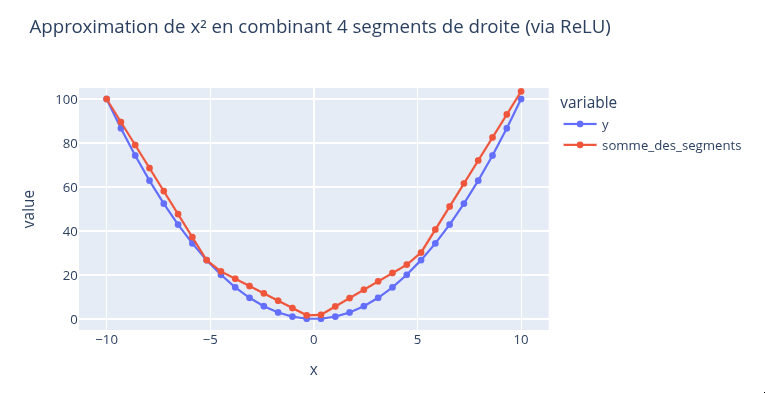

En particulier : si on ne possède pas assez d'exemples, on a peu de chances de converger. **En bas de quelques milliers d'exemples, c'est difficile d'entraîner correctement un réseau de neurones**.

## Plus de capacité != Mieux

Est-ce que c'est toujours souhaitable, utiliser un algo capable d'apprendre des choses arbitrairement complexes?

&nbsp;

Les réseaux de neurones, c'est vraiment puissant : c'est capable d'approximer n'importe quelle fonction continue arbitraire. C'est tellement puissant que c'est vraiment bon pour faire du **surapprentissage**.

Considérez l'exemple de surapprentissage dont on a parlé quand on a introduit le sujet :


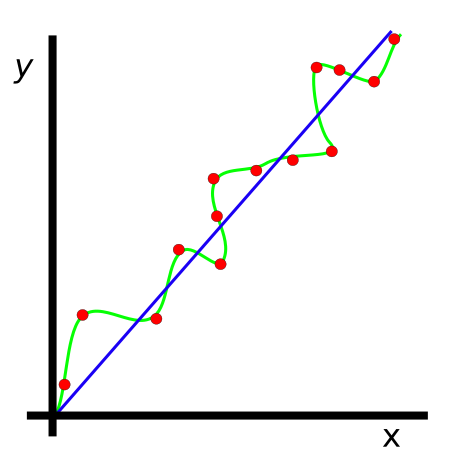


La courbe verte essaie trop fort d'aller chercher des points spécifiques qui ne sont pas forcément représentatifs de tous les points possibles.

Ici, la droite bleue donnait des meilleures performances quand on vérifiait la qualité de la prédiction pour des données de validation.

**Les réseaux de neurones sont tout à fait capables d'apprendre des fonctions inutilement complexes comme la courbe verte**.

&nbsp;

Prenez le jeu de données suivant, disponible dans le *Playground* utilisé plus haut :

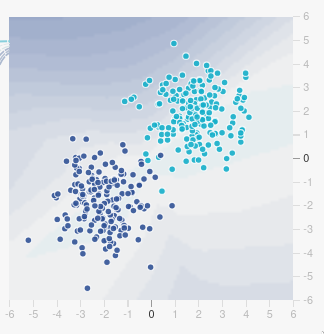

Dans un jeu de données comme ça, SVM avec un hyperparamètre $C$ bien choisi donnerait des excellents résultats.

Avec un réseau de neurones, on peut cependant facilement se retrouver avec une solution qui souffre de surapprentissage :

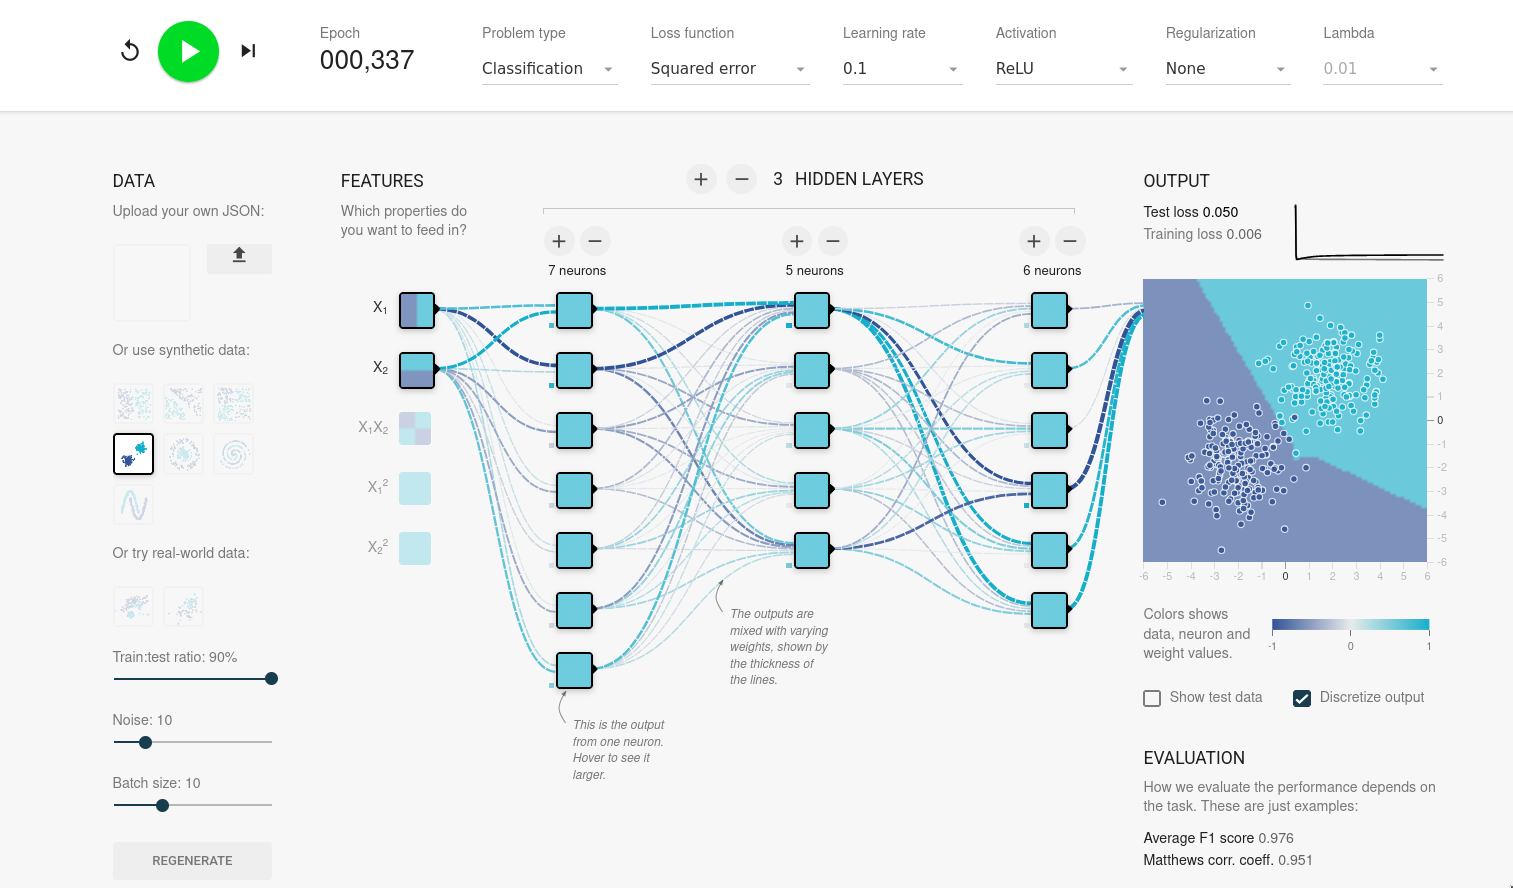

La section qui se tord en plusieurs morceaux pour essayer d'inclure le point pâle ici est un exemple criant de surapprentissage :

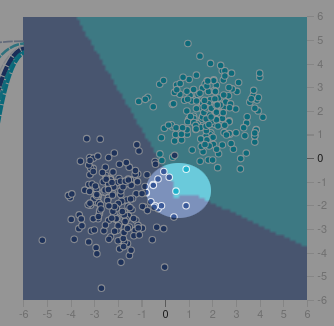

En faisant différents tests avec du bruit, c'est assez facile de se retrouver avec toutes sortes de configurations qui essaient vraiment très fort d'apprendre le bruit des données d'entraînement

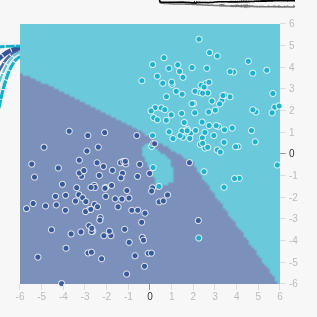

**Notre réseau est capable d'avoir 100% de bonnes réponses sur ses données d'entraînement, mais est-ce que c'est réellement souhaitable ici?**

Clairement pas, le "trou" dans la zone foncée a été créé pour représenter trop fidèlement un point inexact...

Pour mitiger le problème du surapprentissage, il est primordial d'**utiliser de la régularisation**.

&nbsp;

La régression *Ridge* utilisait une pénalité L2 sur les coefficients appris. On peut inclure cette pénalité dans la formule d'erreur de notre réseau de neurones :

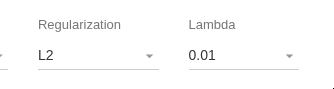

*Notez: "lambda" est le nom donné dans cet outil. Dans `sklearn`, c'était plutôt "alpha", mais c'est la même chose en bout de ligne.*

&nbsp;

Les modèles de `sklearn` ont un hyperparamètre `alpha=0.0001` par défaut qui contrôle la force de cette régularisation.


### Autres formes de régularisation

Le concept de régularisation décrit *des techniques qui ont pour objectif de réduire la capacité d'un modèle*, question d'empêcher le modèle de "trop bien apprendre" les données d'entraînement.

Ajouter une pénalité dans la fonction de perte pour dissuader les gros coefficients, c'est une possibilité, mais il en existe beaucoup d'autres, par exemple : l'**arrêt prématuré** de l'entraînement. Si on stoppe l'entraînement un peu d'avance, alors que la fonction de perte n'a pas encore tout à fait atteint son minimum, on réduit un peu la qualité du modèle sur les données d'entraînement, ce qui peut aider à mieux généraliser sur les nouvelles données.

# Comment on sait comment  on doit configurer un réseau de neurones pour une certaine tâche?

Le nombre de couches à utiliser, le nombre de neurones par couches, la fonction d'activation à choisir, le taux d'apprentissage, le taux de régularisation... Ce sont des choses qui doivent avoir été décidées avant de commencer l'entraînement du réseau de neurone. **Ce sont des hyperparamètres**.

Comment on choisit des hyperparamètres? On en teste plein et on regarde ce qui marche le mieux avec notre problème.

&nbps;

Pour la régression Ridge et pour le SVM, on avait un seul hyperparamètre à trouver, ce qui donnait quelque chose comme :

```python
for valeur in valeurs possibles:
    entraîner le modèle
    calculer l'erreur de validation
```

Pour Ridge, on pouvait tester une dizaine de valeurs pour le taux de régularisation $\alpha$. Pour SVM, on testait une dizaine de paramètres pour $C$, qui contrôle la tolérance aux erreurs.

&nbsp;

Sur des gros problèmes, on pouvait facilement s'attendre à avoir besoin d'un bon gros ~1min pour entraîner et évaluer un modèle.

Si on voulait tester 10 valeurs différentes pour notre hyperparamètre, ça voulait dire ~10min.

&nbsp;

Les réseaux de neurones ont plus qu'un seul hyperparamètre... Au gros minimum, on doit choisir :

1. Le nombre de couches et le nombre de neurones
2. La fonction d'activation
3. Le taux d'apprentissage
4. Le taux de régularisation

&nbsp;

Qu'est-ce qui va se passer si on fait :

```python
for valeur1 in valeur possibles pour hyperparamètre #1:
  for valeur2 in valeur possibles pour hyperparamètre #2:
    for valeur3 in valeur possibles pour hyperparamètre #3:
      for valeur4 in valeur possibles pour hyperparamètre #4:
        entraîner le modèle avec ces hyperparamètres
        calculer l'erreur de validation
```

Si l'entraînement d'un modèle prend ~1min et qu'on a 10 possibilités à tester pour chaque hyperparamètre, chaque boucle **multiplie par 10 le nombre d'entraînements de modèles à tester**.

On a une **croissance exponentielle du temps d'entraînement en fonction du nombre d'hyperparamètres à choisir**.

&nbsp;

À 4 hyperparamètres à tester, on a $10^4 = 10~000$ modèles à entraîner. À 1min par modèle, ça voudrait dire **10 000 minutes** ($\approx$ 166h, ou $\approx$ 7 jours).

> *Et 1min pour faire un entraînement, c'est optimiste... Si on essayait de prédire des images, ça pourrait facilement prendre plusieurs dizaines de minutes ou encore plusieurs heures pour entraîner chaque version du réseau de neurones)*

&nbsp;

On a aussi la possibilité de jouer avec la tolérance de la descente de gradient, de tester différentes fonctions d'activation, de tester différents types de régularisation, de tester différentes fonctions de perte à minimiser...


On ne peut **pas** tester toutes les possibilités...

&nbsp;

Une stratégie possible est d'y aller **en échantillonnant au hasard les possibilités** :

- On se choisit des intervalles de valeurs possibles pour nos hyperparamètres
- On teste un nombre fixe de combinaisons d'hyperparamètres tirées au hasard, par exemple :

- 50 entraînements avec des hyperparamètres au hasard :
    - Taux de régularisation au hasard parmi [0.001, 0.01, 0.1, 1]
    - Taux d'apprentissage au hasard parmi [0.0001, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
    - Nombre de couches au hasard, choisi au hasard entre 3 et 10
    - Nombre de neurones de chaque couche choisi au hasard parmi [10, 25, 50, 100, 200, 400, 1000]

## Largeur vs Profondeur

Supposons qu'on veut un réseau avec un total de 1000 neurones cachés, comment devrait-on organiser les couches?

- 1 couche x 1000 neurones
- 2 couches x 500 neurones
- 10 couches x 10 neurones

&nbsp;

Il n'y a pas de bonne réponse unique, ça dépend toujours de notre problème spécifique, mais *en général* :

- Un réseau trop large (beaucoup de neurones dans une même couche) va avoir tendance à faire du surapprentissage
- Un réseau mince mais profond (beaucoup de couches) va avoir tendance à mieux généraliser

&nbsp;

**Les réseaux profonds sont généralement meilleurs que les réseaux larges**, mais ils sont également beaucoup plus difficiles à entraîner correctement.

# En résumé

- Un **réseau de neurones** est un algorithme d'apprentissage qui permet d'**apprendre tout seul la non-linéarité dans les données**
    - La non-linéarité est apprise en approximant la fonction à coups de combinaisons de neurones en cascade
    - Une combinaison linéaire de plusieurs droites, ça reste une droite. Une somme pondérée de plusieurs sommes pondéré, c'est encore une somme pondérée. Un réseau de neurones doit donc utiliser des fonctions non-linéaires, qu'on appelle **fonctions d'activation** dans le contexte
- Un **neurone** = une combinaison linéaire (somme pondérée et ordonnée à l'origine) + une **fonction d'activation**
- La fonction $ReLU()$ est une fonction d'activation simple, mais il en existe beaucoup d'autres (ex.: $tanh$)
- Un réseau est composé de :
    - **Couche d'entrée** (données)
    - **Couche(s) cachées** (la section qui apprend la non-linéarité)
    - **Couche de sortie** (typiquement une classification ou régression linéaire finale)
- L'entraînement se fait nécessairement avec une **descente de gradient**
- Des **théorèmes d'approximation universelle** démontrent formellement qu'un réseau de neurones suffisamment complexe peut approximer n'importe quelle fonction continue (sur un intervalle donné, à un niveau de précision désiré)
- Trop de capacité peut être un problème, ça peut mener à du **surapprentissage**
- Les réseaux de neurones ont **trop d'hyperparamètres** pour qu'on puisse tous les essayer : il y a une explosion combinatoire, on commence généralement plutôt par en **tester plusieurs au hasard**

## Exercice bonus: dériver un réseau de neurones

Si c'est la descente de gradient qui est utilisée pour faire un entraînement, derrière, il doit y avoir une dérivée de la fonction d'erreur.

### Fonction définie par un réseau de neurones simple

**Bonus 1** Soit le neurone suivant :

- $neurone(x_1, x_2) = ReLU(m_1 x_1 + m_2 x_2 + b)$

Supposons qu'on utilise un seul neurone pour faire une régression, en cherchant à minimiser les *moindres carrés*.

Définissez la fonction d'erreur en supposant que vous avez un jeu de données avec des $(x_\text{i,1}, x_\text{i,2}, y_i)$.

&nbsp;

**Bonus 2**

Dérivez votre fonction d'erreur par rapport à $m_1$, à $m_2$ et à $b$.

Quelle est la dérivée d'un $ReLU$?

&nbsp;

**Bonus 3**

Seriez-vous capables de trouver la *dérivée seconde*? Il y a quelque chose de bizarre qui se passe avec les $ReLU$...

&nbsp;

**Bonus 4** Dérivez la fonction d'erreur d'un réseau de neurones qui a :

- Deux variables d'entrée $x_1$, $x_2$
- Une seule couche cachée, avec deux neurones ReLU
- Un neurone de sorti, pas de ReLU sur ce dernier neurone (seulement une combinaison linéaire des deux neurones cachés)

Définissez la fonction résultante pour ce réseau et dérivez-la par rapport à **chaque paramètre** (certaines dérivées de paramètres vont se ressembler)